# SPA vs Baselines — Results Analysis
Run this notebook from `~/FedLLM-Re/rework/` on the server.

In [51]:
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

RESULTS_DIR = "results/yelp"

METHODS = ["homo_r4", "homo_r8", "hetero_pad", "flexlora", "hetero_spa", "spa_m"]
LABELS  = {
    "homo_r4":    "FedAvg r=4",
    "homo_r8":    "FedAvg r=8",
    "hetero_pad": "Hetero-Pad",
    "flexlora":   "FlexLoRA",
    "hetero_spa": "SPA",
    "spa_m":      "SPA-M (Ours)",
}
COLORS = {
    "homo_r4":    "#9e9e9e",
    "homo_r8":    "#607d8b",
    "hetero_pad": "#ff7043",
    "flexlora":   "#42a5f5",
    "hetero_spa": "#e53935",
    "spa_m":      "#6a0dad",
}
LS = {
    "homo_r4": ":", "homo_r8": "--",
    "hetero_pad": "-.", "flexlora": "--", "hetero_spa": "-.", "spa_m": "-"
}
LW = {
    "homo_r4": 1.2, "homo_r8": 1.2,
    "hetero_pad": 1.5, "flexlora": 2.0, "hetero_spa": 1.8, "spa_m": 2.5
}

def load_all():
    data = defaultdict(lambda: defaultdict(list))
    files = glob.glob(os.path.join(RESULTS_DIR, "*.json"))
    files = [f for f in files if "(1)" not in f]  # skip duplicates
    for f in files:
        with open(f) as fh:
            d = json.load(fh)
        method = d["method"]
        alpha  = d["alpha"]
        data[(method, alpha)]["runs"].append(d)
    return data

def get_curve(runs, metric, scale=1.0):
    per_round = defaultdict(list)
    for run in runs:
        for r in run["rounds"]:
            if metric in r:
                per_round[r["round"]].append(r[metric] * scale)
    rounds, means, stds = [], [], []
    for rnd in sorted(per_round):
        vals = per_round[rnd]
        rounds.append(rnd)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    return np.array(rounds), np.array(means), np.array(stds)

def final_metrics(runs, metrics):
    result = {}
    for metric in metrics:
        vals = [r["rounds"][-1].get(metric, np.nan) for r in runs]
        vals = [v for v in vals if not np.isnan(v)]
        if vals:
            result[metric] = (np.mean(vals), np.std(vals), len(vals))
        else:
            result[metric] = (np.nan, np.nan, 0)
    return result

DATA = load_all()
available = sorted(DATA.keys())
print("Available results:")
for (m, a) in available:
    n = len(DATA[(m,a)]["runs"])
    print(f"  {m:15s}  alpha={a}  seeds={n}")

Available results:
  flexlora         alpha=0.1  seeds=4
  flexlora         alpha=0.5  seeds=5
  hetero_pad       alpha=0.1  seeds=3
  hetero_pad       alpha=0.5  seeds=5
  hetero_spa       alpha=0.1  seeds=4
  hetero_spa       alpha=0.5  seeds=5
  homo_r4          alpha=0.1  seeds=4
  homo_r4          alpha=0.5  seeds=5
  homo_r8          alpha=0.1  seeds=4
  homo_r8          alpha=0.5  seeds=5
  spa_m            alpha=0.1  seeds=4
  spa_m            alpha=0.5  seeds=4


## 1. Convergence Curves — Accuracy

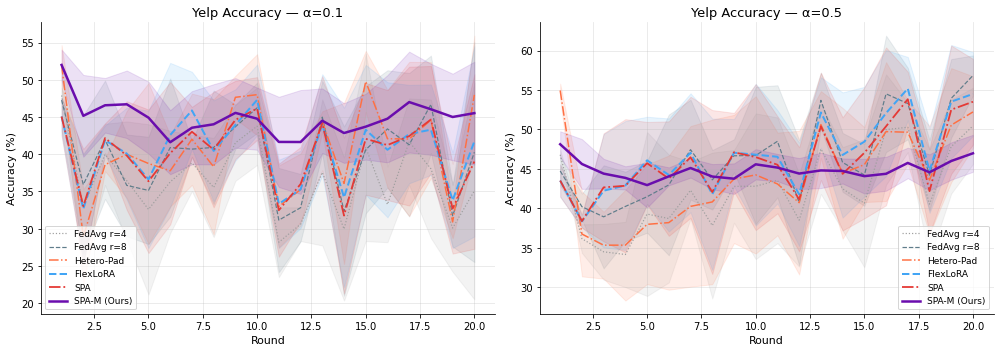

Saved: figures/convergence_accuracy.pdf


In [52]:
alphas = sorted(set(a for _, a in available))
fig, axes = plt.subplots(1, len(alphas), figsize=(7*len(alphas), 5), sharey=False)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    for method in METHODS:
        key = (method, alpha)
        if key not in DATA:
            continue
        runs = DATA[key]["runs"]
        rounds, means, stds = get_curve(runs, "accuracy", scale=100)
        if len(rounds) == 0:
            continue
        ax.plot(rounds, means,
                label=LABELS[method], color=COLORS[method],
                linestyle=LS[method], linewidth=LW[method])
        if len(runs) > 1:
            ax.fill_between(rounds, means-stds, means+stds,
                            alpha=0.12, color=COLORS[method])
    ax.set_title(f"Yelp Accuracy — α={alpha}", fontsize=13)
    ax.set_xlabel("Round", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/convergence_accuracy.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: figures/convergence_accuracy.pdf")

## 2. Convergence Curves — F1-macro

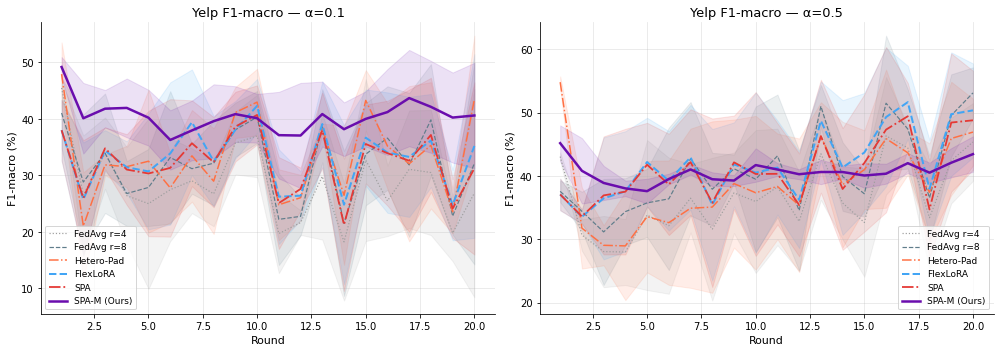

In [53]:
fig, axes = plt.subplots(1, len(alphas), figsize=(7*len(alphas), 5), sharey=False)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    for method in METHODS:
        key = (method, alpha)
        if key not in DATA:
            continue
        runs = DATA[key]["runs"]
        rounds, means, stds = get_curve(runs, "f1_macro", scale=100)
        if len(rounds) == 0:
            continue
        ax.plot(rounds, means,
                label=LABELS[method], color=COLORS[method],
                linestyle=LS[method], linewidth=LW[method])
        if len(runs) > 1:
            ax.fill_between(rounds, means-stds, means+stds,
                            alpha=0.12, color=COLORS[method])
    ax.set_title(f"Yelp F1-macro — α={alpha}", fontsize=13)
    ax.set_xlabel("Round", fontsize=11)
    ax.set_ylabel("F1-macro (%)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/convergence_f1.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 3. Perplexity Convergence

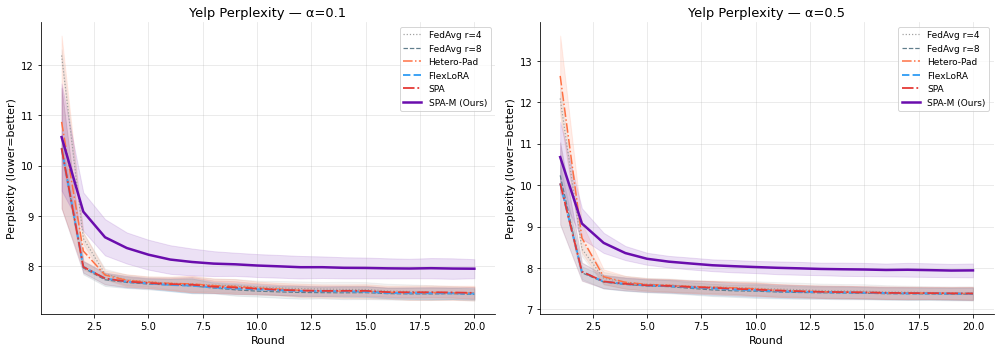

In [54]:
fig, axes = plt.subplots(1, len(alphas), figsize=(7*len(alphas), 5), sharey=False)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    for method in METHODS:
        key = (method, alpha)
        if key not in DATA:
            continue
        runs = DATA[key]["runs"]
        rounds, means, stds = get_curve(runs, "perplexity")
        if len(rounds) == 0:
            continue
        ax.plot(rounds, means,
                label=LABELS[method], color=COLORS[method],
                linestyle=LS[method], linewidth=LW[method])
        if len(runs) > 1:
            ax.fill_between(rounds, means-stds, means+stds,
                            alpha=0.12, color=COLORS[method])
    ax.set_title(f"Yelp Perplexity — α={alpha}", fontsize=13)
    ax.set_xlabel("Round", fontsize=11)
    ax.set_ylabel("Perplexity (lower=better)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/convergence_perplexity.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 4. SPA vs FlexLoRA Head-to-Head

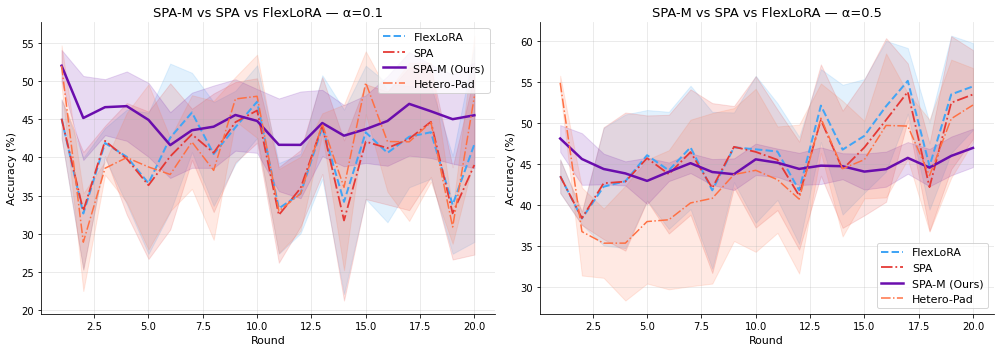

In [55]:
fig, axes = plt.subplots(1, len(alphas), figsize=(7*len(alphas), 5))
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    for method in ["flexlora", "hetero_spa", "spa_m","hetero_pad"]:
        key = (method, alpha)
        if key not in DATA:
            continue
        runs = DATA[key]["runs"]
        rounds, means, stds = get_curve(runs, "accuracy", scale=100)
        ax.plot(rounds, means,
                label=LABELS[method], color=COLORS[method],
                linestyle=LS[method], linewidth=LW[method])
        if len(runs) > 1:
            ax.fill_between(rounds, means-stds, means+stds,
                            alpha=0.15, color=COLORS[method])
    ax.set_title(f"SPA-M vs SPA vs FlexLoRA — α={alpha}", fontsize=13)
    ax.set_xlabel("Round", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/spa_vs_flexlora.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 5. Final Round Summary Table

In [56]:
METRICS = ["accuracy", "f1_macro", "perplexity"]
SCALE   = {"accuracy": 100, "f1_macro": 100, "perplexity": 1}
HIGHER  = {"accuracy", "f1_macro"}

alphas = sorted(set(a for _, a in DATA.keys()))

for alpha in alphas:
    print(f"\n{'='*70}")
    print(f"YELP — α={alpha} — Final Round (mean ± std over seeds)")
    print(f"{'='*70}")
    print(f"{'Method':<18} {'Accuracy':>14} {'F1-macro':>14} {'Perplexity':>14} {'Seeds'}")
    print("-"*70)

    rows = {}
    for method in METHODS:
        key = (method, alpha)
        if key not in DATA:
            continue
        rows[method] = final_metrics(DATA[key]["runs"], METRICS)

    best = {}
    for metric in METRICS:
        vals = [(m, rows[m][metric][0]) for m in rows if not np.isnan(rows[m][metric][0])]
        if vals:
            best[metric] = max(vals, key=lambda x: x[1])[0] if metric in HIGHER else min(vals, key=lambda x: x[1])[0]

    for method in METHODS:
        if method not in rows:
            continue
        fm = rows[method]
        cells = []
        for metric in METRICS:
            mean, std, n = fm[metric]
            s = SCALE[metric]
            if np.isnan(mean):
                cells.append(f"{'—':>14}")
            else:
                tag = "*" if best.get(metric) == method else " "
                cells.append(f"{mean*s:>6.2f}±{std*s:<5.2f}{tag}")
        n = len(DATA[(method, alpha)]["runs"])
        marker = " <<<" if method == "spa_m" else ""
        print(f"{LABELS[method]:<18} {'  '.join(cells)}  n={n}{marker}")

print("\n* = best in column")


YELP — α=0.1 — Final Round (mean ± std over seeds)
Method                   Accuracy       F1-macro     Perplexity Seeds
----------------------------------------------------------------------
FedAvg r=4          35.09±14.56    26.85±18.47     7.46±0.13    n=4
FedAvg r=8          40.28±14.76    32.11±17.90     7.44±0.12 *  n=4
Hetero-Pad          47.97±7.95 *   43.43±11.33*    7.46±0.15    n=3
FlexLoRA            41.73±12.77    35.20±16.28     7.45±0.12    n=4
SPA                 39.02±11.72    31.22±15.26     7.47±0.12    n=4
SPA-M (Ours)        45.52±6.91     40.61±9.34      7.95±0.19    n=4 <<<

YELP — α=0.5 — Final Round (mean ± std over seeds)
Method                   Accuracy       F1-macro     Perplexity Seeds
----------------------------------------------------------------------
FedAvg r=4          50.45±4.83     45.36±6.14      7.40±0.16    n=5
FedAvg r=8          56.84±2.55 *   53.11±4.03 *    7.37±0.15 *  n=5
Hetero-Pad          52.22±4.53     46.93±5.27      7.38±0.15    n=

## 6. Bar Chart — Final Accuracy Comparison

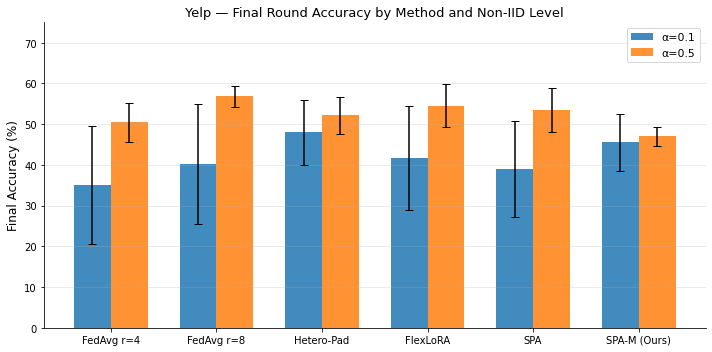

In [57]:
methods_avail = [m for m in METHODS if any((m, a) in DATA for a in alphas)]
x = np.arange(len(methods_avail))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, alpha in enumerate(alphas):
    means, errs = [], []
    for method in methods_avail:
        key = (method, alpha)
        if key in DATA:
            fm = final_metrics(DATA[key]["runs"], ["accuracy"])
            m, s, _ = fm["accuracy"]
            means.append(m * 100 if not np.isnan(m) else 0)
            errs.append(s * 100 if not np.isnan(s) else 0)
        else:
            means.append(0)
            errs.append(0)
    offset = (i - len(alphas)/2 + 0.5) * width
    bars = ax.bar(x + offset, means, width,
                  label=f"α={alpha}",
                  yerr=errs, capsize=4,
                  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[m] for m in methods_avail], fontsize=10)
ax.set_ylabel("Final Accuracy (%)", fontsize=12)
ax.set_title("Yelp — Final Round Accuracy by Method and Non-IID Level", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
ax.set_ylim(0, 75)

plt.tight_layout()
plt.savefig("figures/bar_final_accuracy.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 7. Per-Seed Scatter — SPA vs FlexLoRA

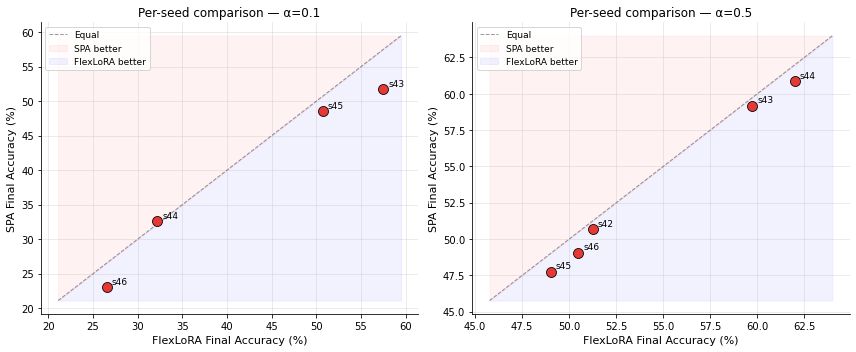

In [58]:
fig, axes = plt.subplots(1, len(alphas), figsize=(6*len(alphas), 5))
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    spa_key  = ("hetero_spa", alpha)
    flex_key = ("flexlora",   alpha)
    if spa_key not in DATA or flex_key not in DATA:
        ax.set_title(f"No data for α={alpha}")
        continue

    spa_runs  = {r["seed"]: r["rounds"][-1]["accuracy"]*100 for r in DATA[spa_key]["runs"]}
    flex_runs = {r["seed"]: r["rounds"][-1]["accuracy"]*100 for r in DATA[flex_key]["runs"]}
    seeds = sorted(set(spa_runs) & set(flex_runs))

    spa_vals  = [spa_runs[s]  for s in seeds]
    flex_vals = [flex_runs[s] for s in seeds]

    # Scatter
    ax.scatter(flex_vals, spa_vals, s=100, zorder=5,
               color="#e53935", edgecolors="black", linewidth=0.8)
    for i, s in enumerate(seeds):
        ax.annotate(f"s{s}", (flex_vals[i], spa_vals[i]),
                    textcoords="offset points", xytext=(5,3), fontsize=9)

    # Diagonal = equal performance
    lims = [min(flex_vals+spa_vals)-2, max(flex_vals+spa_vals)+2]
    ax.plot(lims, lims, "k--", alpha=0.4, linewidth=1, label="Equal")
    ax.fill_between(lims, lims, [lims[1]]*2, alpha=0.05, color="red", label="SPA better")
    ax.fill_between(lims, [lims[0]]*2, lims, alpha=0.05, color="blue", label="FlexLoRA better")

    ax.set_xlabel("FlexLoRA Final Accuracy (%)", fontsize=11)
    ax.set_ylabel("SPA Final Accuracy (%)", fontsize=11)
    ax.set_title(f"Per-seed comparison — α={alpha}", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/scatter_spa_vs_flexlora.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 8. LaTeX Table (paste directly into paper)

In [48]:
print("% ============================================================")
print("% Table: Yelp Results")
print("% ============================================================")
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\begin{tabular}{lcccccc}")
print(r"\toprule")
print(r" & \multicolumn{3}{c}{$\alpha=0.5$} & \multicolumn{3}{c}{$\alpha=0.1$} \\")
print(r"\cmidrule(lr){2-4} \cmidrule(lr){5-7}")
print(r"Method & Acc. & F1 & PPL & Acc. & F1 & PPL \\")
print(r"\midrule")

for method in METHODS:
    row_cells = []
    for alpha in [0.5, 0.1]:
        key = (method, alpha)
        if key in DATA:
            fm = final_metrics(DATA[key]["runs"], METRICS)
            for metric in METRICS:
                mean, std, n = fm[metric]
                s = SCALE[metric]
                if np.isnan(mean):
                    row_cells.append("—")
                else:
                    row_cells.append(f"{mean*s:.2f}$_{{\\pm {std*s:.2f}}}$")
        else:
            row_cells.extend(["—", "—", "—"])

    label = LABELS[method]
    row = f"{label} & " + " & ".join(row_cells) + r" \\"
    if method == "hetero_spa":
        row = r"\rowcolor{gray!15} " + row
    print(row)

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\caption{Yelp-5 results. Mean $\pm$ std over seeds. PPL = perplexity (lower is better). Bold = best.}")
print(r"\label{tab:yelp}")
print(r"\end{table}")

% ============================================================
% Table: Yelp Results
% ============================================================
\begin{table}[h]
\centering
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{$\alpha=0.5$} & \multicolumn{3}{c}{$\alpha=0.1$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Method & Acc. & F1 & PPL & Acc. & F1 & PPL \\
\midrule
FedAvg r=4 & 50.45$_{\pm 4.83}$ & 45.36$_{\pm 6.14}$ & 7.40$_{\pm 0.16}$ & 35.09$_{\pm 14.56}$ & 26.85$_{\pm 18.47}$ & 7.46$_{\pm 0.13}$ \\
FedAvg r=8 & 56.84$_{\pm 2.55}$ & 53.11$_{\pm 4.03}$ & 7.37$_{\pm 0.15}$ & 40.28$_{\pm 14.76}$ & 32.11$_{\pm 17.90}$ & 7.44$_{\pm 0.12}$ \\
Hetero-Pad & 52.22$_{\pm 4.53}$ & 46.93$_{\pm 5.27}$ & 7.38$_{\pm 0.15}$ & 47.97$_{\pm 7.95}$ & 43.43$_{\pm 11.33}$ & 7.46$_{\pm 0.15}$ \\
FlexLoRA & 54.50$_{\pm 5.30}$ & 50.35$_{\pm 7.41}$ & 7.38$_{\pm 0.15}$ & 41.73$_{\pm 12.77}$ & 35.20$_{\pm 16.28}$ & 7.45$_{\pm 0.12}$ \\
\rowcolor{gray!15} SPA & 53.51$_{\pm 5.43}$ & 48.78$_{\pm 7.82}$ &